# Customer Clustering (Unsupervised)
This notebook segments customers using K-means clustering on scaled RFM features. We'll scale the data, determine optimal k with elbow and silhouette plots, fit the model, assign cluster labels, visualize results, log experiments with MLflow, and save outputs

## 1. Load and Scale RFM Features
Load the RFM DataFrame and scale the features (Recency, Frequency, Monetary) using StandardScaler to ensure equal weighting in clustering

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load RFM features
rfm = pd.read_csv('data/rfm_features.csv')

# Scale RFM features (use numpy array for fitting)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

## 2. Elbow Plot for Optimal K
Compute inertia for k=1 to 10 and plot the elbow curve to identify a potential optimal number of clusters (look for the "elbow" where inertia decreases slow down).

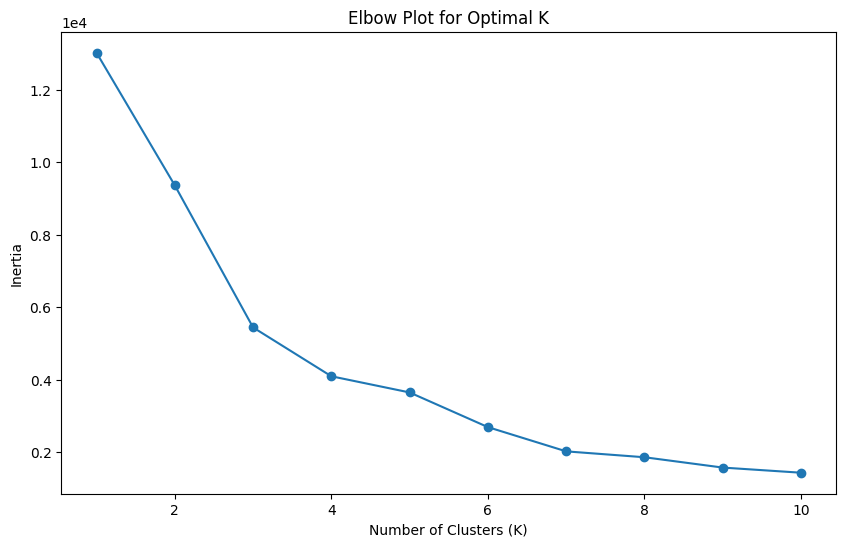

In [2]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Elbow plot for optimal k (inertia)
inertia = []
k_range = range(1, 11)
for k in k_range:
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit(rfm_scaled)
  inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o')
plt.title("Elbow Plot for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.show()

## 3. Silhouette Scores for Different K
Compute silhouette scores for k=2 to 10 (measures cluster cohesion/separation) and plot to help select k (higher score is better, look for peaks).

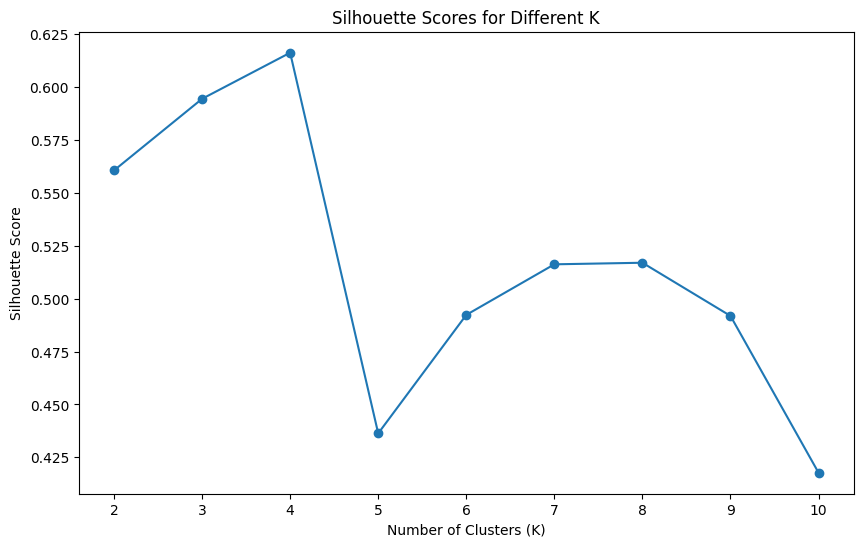

In [3]:
from sklearn.metrics import silhouette_score

# Silhouette scores for k=2 to 10
sil_scores = []
for k in range(2, 11):
  kmeans = KMeans(n_clusters=k, random_state=42)
  clusters = kmeans.fit_predict(rfm_scaled)
  sil_scores.append(silhouette_score(rfm_scaled, clusters))

plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), sil_scores, marker='o')
plt.title("Silhouette Scores for Different K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.show()

## 4. Fit K-Means and Assign Cluster Labels
Choose k based on the plots, fit the KMeans model, and add the 'Cluster' labels to the RFM DataFrame.

In [4]:
# Choose k based on plots
k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

## 5. Visualize Clusters
Create scatterplots to visualize the clusters (e.g., Recency vs Monetary, Frequency vs Monetary, colored by Cluster) to interpret the segments. 

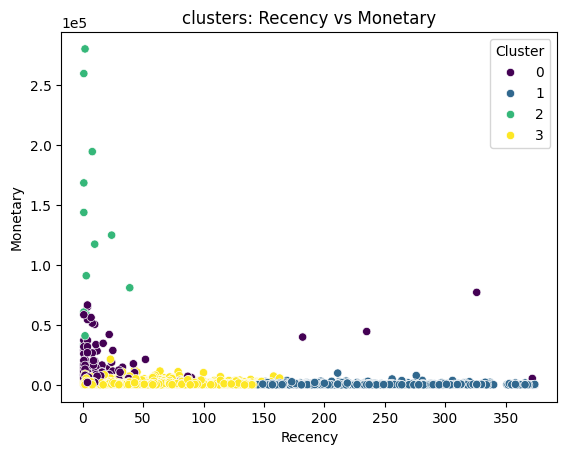

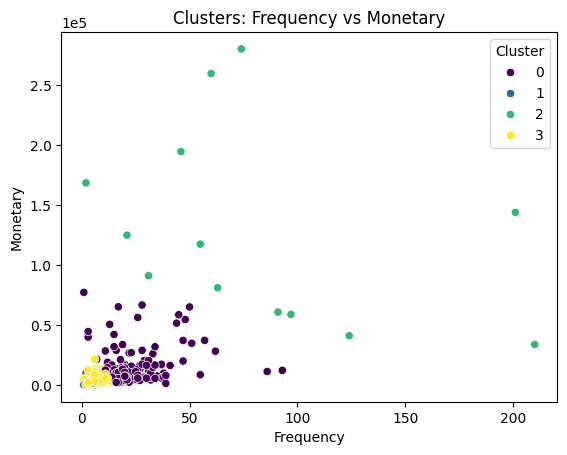

In [5]:
import seaborn as sns

# Visualize clusters (scatterplots)
sns.scatterplot(x='Recency', y='Monetary', hue='Cluster', data=rfm, palette='viridis')
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.title("clusters: Recency vs Monetary")
plt.show()

sns.scatterplot(x='Frequency', y='Monetary', hue='Cluster', data=rfm, palette='viridis')
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.title("Clusters: Frequency vs Monetary")
plt.show()

## 6. Log Experiment with MLflow
Set up an MLflow experiment, log parameters/metrics (e.g., k, inertia, silhouette), the model, and artifacts (e.g., plots) for tracking.

In [6]:
import mlflow

# Log experiment with MLflow
mlflow.set_experiment("Customer_Clustering")
with mlflow.start_run(run_name="KMeans_RFM_k4"):
    mlflow.log_param("n_clusters", k)
    mlflow.log_metric("inertia", kmeans.inertia_)
    sil = silhouette_score(rfm_scaled, rfm['Cluster'])
    mlflow.log_metric("silhouette_score", sil)
    mlflow.sklearn.log_model(kmeans, "kmeans_model")
    # Save and log plots as artifacts (example for elbow; repeat for others if needed)
    plt.savefig('elbow_plot.png')  # Note: This saves the last active plot; save each plot separately in practice
    mlflow.log_artifact('elbow_plot.png')
    print("MLflow run logged successfully")

2025/09/24 20:54:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/24 20:54:21 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


MLflow run logged successfully


<Figure size 640x480 with 0 Axes>

## 7. Save Outputs
Save the updated RFM DataFrame with cluster labels as a CSV for use in later days.

In [7]:
# Save RFM with cluster labels
rfm.to_csv('data/rfm_with_clusters.csv', index=False)
print("RFM with clusters saved as 'data/rfm_with_clusters.csv'")

RFM with clusters saved as 'data/rfm_with_clusters.csv'


## 8. Ethical Considerations and Bias Check
Quick check for potential biases (e.g., country-based clustering skew). Visualize cluster distribution by country to spot issues like over-representation.

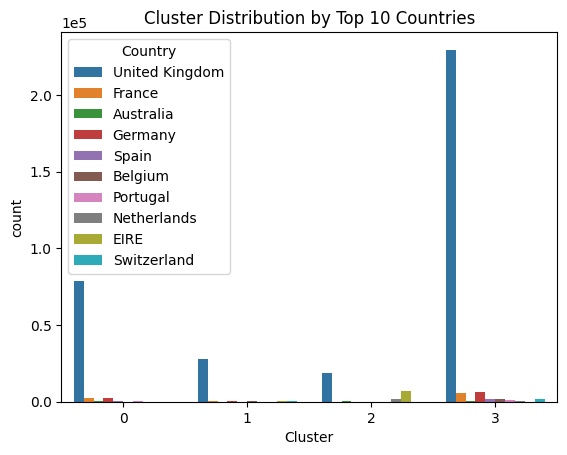

Ethical note: Watch for biases—e.g., UK may dominate due to dataset skew; adjust features if needed for fairness.


In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load cleaned data and RFM with clusters (from Day 3)
df_clean = pd.read_csv('data/clean_online_retail.csv')  # Corrected filename (was 'clean_online_retail.csv')
rfm = pd.read_csv('data/rfm_with_clusters.csv')

# Merge clusters back to original data
df_clean_with_clusters = df_clean.merge(rfm[['CustomerID', 'Cluster']], on='CustomerID', how='left')

# Visualize cluster distribution by top countries (check for bias)
top_countries = df_clean_with_clusters['Country'].value_counts().head(10).index
sns.countplot(x='Cluster', hue='Country', data=df_clean_with_clusters[df_clean_with_clusters['Country'].isin(top_countries)])  # Fixed 'Clusters' to 'Cluster'
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.title('Cluster Distribution by Top 10 Countries')
plt.show()

# Note: If one country (e.g., UK) dominates clusters, consider debiasing (e.g., stratified sampling) in future iterations.
print("Ethical note: Watch for biases—e.g., UK may dominate due to dataset skew; adjust features if needed for fairness.")

## 9. Bias Analysis and Confirmation
Based on the cluster distribution plot from Section 8, we observe potential geographic biases: The UK dominates all clusters (e.g., ~99% of counts in each, with non-UK countries barely visible). This likely stems from dataset imbalance (~90% UK data), leading to clusters that may reflect country-specific patterns rather than pure RFM behaviors. Implications: Reduced model generalizability for international customers, potential discrimination (e.g., non-UK users get suboptimal personalizations), and ethical concerns (violating fair ML). Below, we confirm biases quantitatively with percentage breakdowns per cluster and metrics like Adjusted Rand Index (ARI) to measure overlap between clusters and countries (ARI near 1 indicates high correlation/bias; near 0 is random/no bias).

Percentage of Countries per Cluster (Top 5 per Cluster):

Cluster 0:
Country
United Kingdom    92.913423
France             2.826834
Germany            2.481897
Spain              0.564658
Portugal           0.438260
Name: proportion, dtype: float64

Cluster 1:
Country
United Kingdom    90.720632
Germany            2.119118
France             1.398486
Belgium            0.582428
Switzerland        0.536361
Name: proportion, dtype: float64

Cluster 2:
Country
United Kingdom    65.344519
EIRE              24.841167
Netherlands        7.301064
Australia          2.513251
Name: proportion, dtype: float64

Cluster 3:
Country
United Kingdom    90.217067
Germany            2.475314
France             2.171452
Spain              0.753955
Belgium            0.707569
Name: proportion, dtype: float64

Adjusted Rand Index (ARI) between Cluster and Country: 0.0396
Interpretation: ARI near 1 = strong bias (clusters aligned with countries); near 0 = no bias (random). If high, debias needed.


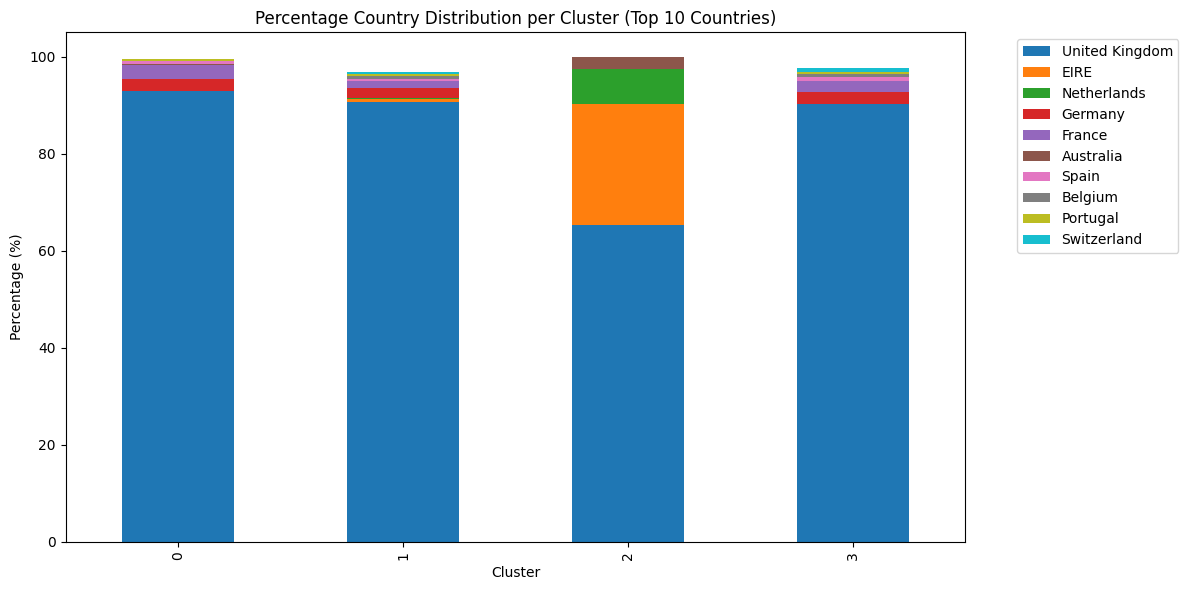

In [13]:
from sklearn.metrics import adjusted_rand_score

# Assume df_clean_with_clusters from Section 8 (with 'Cluster' merged)

# Confirm bias: Percentage of each cluster by country
cluster_country_pct = df_clean_with_clusters.groupby('Cluster')['Country'].value_counts(normalize=True) * 100
print("Percentage of Countries per Cluster (Top 5 per Cluster):")
for cluster in sorted(df_clean_with_clusters['Cluster'].unique()):
    print(f"\nCluster {cluster}:")
    print(cluster_country_pct[cluster].head(5))

# ARI to measure overlap between Cluster and Country labels (high ARI = bias)
# Encode Country as numeric labels for ARI
from sklearn.preprocessing import LabelEncoder
country_encoder = LabelEncoder()
df_clean_with_clusters['Country_Label'] = country_encoder.fit_transform(df_clean_with_clusters['Country'])

ari_score = adjusted_rand_score(df_clean_with_clusters['Country_Label'], df_clean_with_clusters['Cluster'])
print(f"\nAdjusted Rand Index (ARI) between Cluster and Country: {ari_score:.4f}")
print("Interpretation: ARI near 1 = strong bias (clusters aligned with countries); near 0 = no bias (random). If high, debias needed.")

# Optional: Visualize percentages as stacked bar plot for clarity
cluster_country_counts = df_clean_with_clusters.groupby(['Cluster', 'Country']).size().unstack(fill_value=0)
cluster_country_counts = cluster_country_counts.div(cluster_country_counts.sum(axis=1), axis=0) * 100  # To percentages
top_countries = cluster_country_counts.sum().nlargest(10).index  # Top 10
cluster_country_counts[top_countries].plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Percentage Country Distribution per Cluster (Top 10 Countries)')
plt.ylabel('Percentage (%)')
plt.xlabel('Cluster')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 10. Pricing Bias Check and Other Potential Biases
In addition to geographic bias, check for pricing bias by examining how clusters relate to average UnitPrice per customer (e.g., do certain clusters favor high/low-priced items, potentially skewing personalization toward premium buyers?). This could indicate if RFM clustering indirectly discriminates by spend level or product affordability. We'll aggregate average UnitPrice per CustomerID, merge with clusters, and visualize distributions/metrics to confirm. Also, briefly check other biases like product type skew (e.g., clusters dominated by certain Descriptions/StockCodes) and time-based bias (e.g., clusters skewed by purchase recency patterns, which might reflect seasonal/dataset artifacts). If biases are high, note for debiasing (e.g., normalize prices or add features).

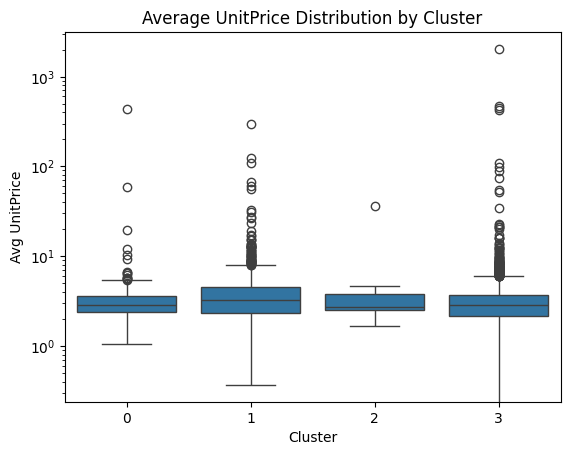

Mean Average UnitPrice per Cluster:
Cluster
0    5.523865
1    4.462899
2    5.553183
3    4.388282
Name: AvgUnitPrice, dtype: float64

Top 5 Products (%) per Cluster (check for skew):
Cluster  Description                       
0        JUMBO BAG RED RETROSPOT               0.571746
         WHITE HANGING HEART T-LIGHT HOLDER    0.523313
         REGENCY CAKESTAND 3 TIER              0.511500
         LUNCH BAG RED RETROSPOT               0.437078
         PARTY BUNTING                         0.429991
1        WHITE HANGING HEART T-LIGHT HOLDER    0.707470
         REGENCY CAKESTAND 3 TIER              0.664692
         PARTY BUNTING                         0.480421
         ASSORTED COLOUR BIRD ORNAMENT         0.454097
         REX CASH+CARRY JUMBO SHOPPER          0.401448
2        JUMBO BAG RED RETROSPOT               0.431746
         REGENCY CAKESTAND 3 TIER              0.372073
         CARRIAGE                              0.340482
         WHITE HANGING HEART T-LIGHT HOLDER

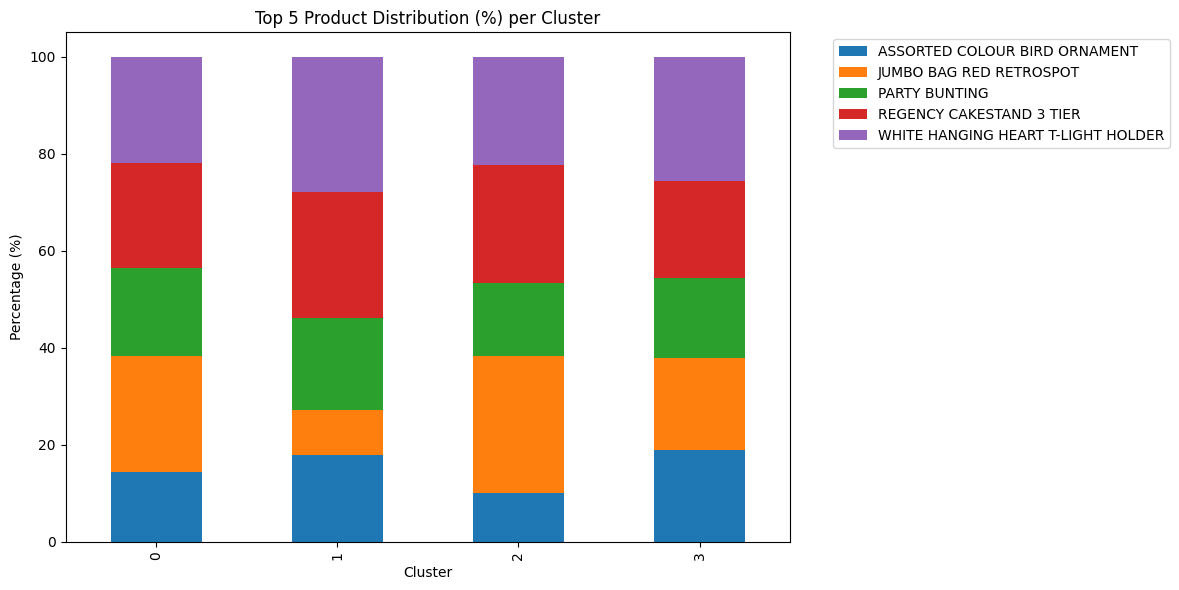

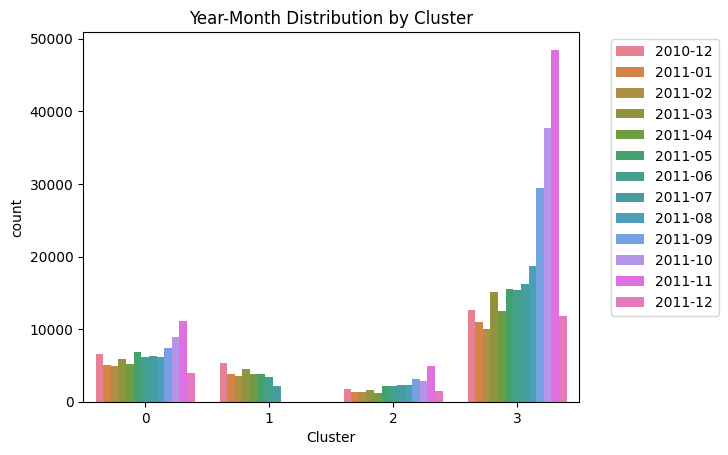


ARI between Cluster and YearMonth: 0.0206 (High = potential time/seasonal bias)


In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load cleaned data and RFM with clusters (from Day 3)
df_clean = pd.read_csv('data/clean_online_retail.csv')  # Corrected filename (was 'clean_online_retail.csv')
rfm = pd.read_csv('data/rfm_with_clusters.csv')

# Merge clusters back to original data (if not already done)
df_clean_with_clusters = df_clean.merge(rfm[['CustomerID', 'Cluster']], on='CustomerID', how='left')

# Ensure YearMonth is present (add if missing from load)
if 'YearMonth' not in df_clean_with_clusters.columns:
    df_clean_with_clusters['InvoiceDate'] = pd.to_datetime(df_clean_with_clusters['InvoiceDate'])
    df_clean_with_clusters['YearMonth'] = df_clean_with_clusters['InvoiceDate'].dt.to_period('M')

# Pricing Bias Check: Aggregate average UnitPrice per CustomerID
customer_avg_price = df_clean_with_clusters.groupby('CustomerID')['UnitPrice'].mean().reset_index(name='AvgUnitPrice')

# Merge with RFM/clusters
rfm_with_price = rfm.merge(customer_avg_price, on='CustomerID')

# Visualize AvgUnitPrice distribution by Cluster
sns.boxplot(x='Cluster', y='AvgUnitPrice', data=rfm_with_price)
plt.title('Average UnitPrice Distribution by Cluster')
plt.ylabel('Avg UnitPrice')
plt.yscale('log')  # Log scale for skew
plt.show()

# Confirm bias: Mean AvgUnitPrice per Cluster
print("Mean Average UnitPrice per Cluster:")
print(rfm_with_price.groupby('Cluster')['AvgUnitPrice'].mean())

# Interpretation: If one cluster has much higher/lower means, potential pricing bias (e.g., premium vs. budget segments).

# Other Bias: Product Type Skew (e.g., top Descriptions per Cluster)
top_products_per_cluster = df_clean_with_clusters.groupby('Cluster')['Description'].value_counts(normalize=True).groupby(level=0).head(5) * 100
print("\nTop 5 Products (%) per Cluster (check for skew):")
print(top_products_per_cluster)

# Visualize (optional stacked bar for top products)
# Pivot and plot top 5 overall products by cluster
top_products = df_clean_with_clusters['Description'].value_counts().head(5).index
product_counts = df_clean_with_clusters[df_clean_with_clusters['Description'].isin(top_products)].groupby(['Cluster', 'Description']).size().unstack(fill_value=0)
product_counts = product_counts.div(product_counts.sum(axis=1), axis=0) * 100  # To percentages
product_counts.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Top 5 Product Distribution (%) per Cluster')
plt.ylabel('Percentage (%)')
plt.xlabel('Cluster')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Other Bias: Time-Based (e.g., YearMonth distribution by Cluster)
sns.countplot(x='Cluster', hue='YearMonth', data=df_clean_with_clusters)
plt.title('Year-Month Distribution by Cluster')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Confirmation Metric: ARI for Cluster vs. YearMonth (high = time bias)
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import adjusted_rand_score
month_encoder = LabelEncoder()
df_clean_with_clusters['YearMonth_Label'] = month_encoder.fit_transform(df_clean_with_clusters['YearMonth'])
ari_time = adjusted_rand_score(df_clean_with_clusters['YearMonth_Label'], df_clean_with_clusters['Cluster'])
print(f"\nARI between Cluster and YearMonth: {ari_time:.4f} (High = potential time/seasonal bias)")

# Notes: If ARI >0.2 or products/prices heavily skewed, consider adding time-normalized features or stratified clustering in future days.